# Notebook 12 — Signal Timing Impact Evaluation

## Objective
Quantify the operational effect of optimized timing relative to baseline timing using comparable scenario-level metrics.

## Background / Context
This final evaluation notebook synthesizes simulation outputs to determine whether the optimization objective translated into measurable operational benefit.

## Methodology
Load paired baseline/optimized outcomes, compute scenario-level changes, evaluate summary metrics, visualize effects, and interpret practical significance.

## Implementation
The sections below preserve existing evaluation logic and focus on clear reporting.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'data').exists() else cwd.parent
processed_dir = repo_root / 'data' / 'processed'

scenario_label_map = {
    'off_peak': 'Off-Peak Demand',
    'off-peak': 'Off-Peak Demand',
    'off peak': 'Off-Peak Demand',
    'off-peak demand': 'Off-Peak Demand',
    'off_peak_demand': 'Off-Peak Demand',
    'normal': 'Normal Demand',
    'normal demand': 'Normal Demand',
    'peak': 'Peak Demand',
    'peak demand': 'Peak Demand',
}
scenario_order = ['Off-Peak Demand', 'Normal Demand', 'Peak Demand']
strategy_order = ['Baseline', 'Optimized']

candidate_paths = [
    processed_dir / 'intersection_simulation_results_enhanced.csv',
    processed_dir / 'intersection_simulation_results.csv',
]

simulation_path = next((path for path in candidate_paths if path.exists()), None)
if simulation_path is None:
    raise FileNotFoundError(
        'Issue #12 simulation outputs are required before Issue #14 can run. '
        'Expected one of the following files: '
        'data/processed/intersection_simulation_results_enhanced.csv or '
        'data/processed/intersection_simulation_results.csv.'
    )

simulation_df = pd.read_csv(simulation_path)
simulation_df['scenario'] = (
    simulation_df['scenario']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(lambda value: scenario_label_map.get(value, value.title().replace('_', ' ')))
)
simulation_df['strategy'] = simulation_df['strategy'].astype(str).str.strip().str.title()
simulation_df['scenario'] = pd.Categorical(simulation_df['scenario'], categories=scenario_order, ordered=True)
simulation_df['strategy'] = pd.Categorical(simulation_df['strategy'], categories=strategy_order, ordered=True)
simulation_df = simulation_df.sort_values(['scenario', 'strategy']).reset_index(drop=True)

required_columns = ['scenario', 'strategy', 'delay', 'throughput', 'queue_pressure', 'demand_served_per_cycle']
missing_columns = [column for column in required_columns if column not in simulation_df.columns]
if missing_columns:
    raise ValueError(f'Missing required simulation columns: {missing_columns}')

optional_columns = [column for column in ['queue_pressure_ratio', 'vc_ratio'] if column in simulation_df.columns]
print(f'Loaded simulation results from: {simulation_path.relative_to(repo_root)}')
print(f'Dataframe shape: {simulation_df.shape}')
print('Columns:')
print(simulation_df.columns.tolist())
print(f'Optional columns available for impact analysis: {optional_columns if optional_columns else "None"}')

display(simulation_df.head())


Loaded simulation results from: data/processed/intersection_simulation_results_enhanced.csv
Dataframe shape: (6, 28)
Columns:
['scenario', 'strategy', 'demand_phase1', 'demand_phase2', 'cycle_length', 'green_phase1', 'green_phase2', 'delay', 'throughput', 'queue_pressure', 'demand_served_per_cycle', 'capacity_phase1', 'capacity_phase2', 'throughput_phase1', 'throughput_phase2', 'queue_phase1', 'queue_phase2', 'total_demand', 'queue_pressure_ratio', 'total_capacity', 'vc_ratio', 'delay_reduction_percent', 'throughput_increase_percent', 'queue_pressure_reduction_percent', 'vc_ratio_baseline', 'vc_ratio_optimized', 'queue_pressure_ratio_baseline', 'queue_pressure_ratio_optimized']
Optional columns available for impact analysis: ['queue_pressure_ratio', 'vc_ratio']


,scenario,strategy,demand_phase1,demand_phase2,cycle_length,green_phase1,green_phase2,delay,throughput,queue_pressure,demand_served_per_cycle,capacity_phase1,capacity_phase2,throughput_phase1,throughput_phase2,queue_phase1,queue_phase2,total_demand,queue_pressure_ratio,total_capacity,vc_ratio,delay_reduction_percent,throughput_increase_percent,queue_pressure_reduction_percent,vc_ratio_baseline,vc_ratio_optimized,queue_pressure_ratio_baseline,queue_pressure_ratio_optimized
0,Off-Peak Demand,Baseline,480.000,300.000,90,45.000,45.000,14.633,780.000,0.000,19.500,900.000,900.000,480.000,300.000,0.000,0.000,780.000,0.000,"1,800.000",0.433,8.073,0.000,NaN,0.433,0.433,0.000,0.000
1,Off-Peak Demand,Optimized,480.000,300.000,90,55.380,34.620,13.452,780.000,0.000,19.500,"1,107.600",692.400,480.000,300.000,0.000,0.000,780.000,0.000,"1,800.000",0.433,8.073,0.000,NaN,0.433,0.433,0.000,0.000
2,Normal Demand,Baseline,800.000,500.000,90,45.000,45.000,18.453,"1,300.000",0.000,32.500,900.000,900.000,800.000,500.000,0.000,0.000,"1,300.000",0.000,"1,800.000",0.722,10.856,0.000,NaN,0.722,0.722,0.000,0.000
3,Normal Demand,Optimized,800.000,500.000,90,55.380,34.620,16.449,"1,300.000",0.000,32.500,"1,107.600",692.400,800.000,500.000,0.000,0.000,"1,300.000",0.000,"1,800.000",0.722,10.856,0.000,NaN,0.722,0.722,0.000,0.000
4,Peak Demand,Baseline,"1,120.000",700.000,90,45.000,45.000,34.465,"1,600.000",220.000,40.000,900.000,900.000,900.000,700.000,220.000,0.000,"1,820.000",0.121,"1,800.000",1.011,35.290,12.500,90.909,1.011,1.011,0.121,0.011


## Results — Baseline vs Optimized Performance Comparison

In [2]:
comparison_metrics = ['delay', 'throughput', 'queue_pressure', 'demand_served_per_cycle']
if 'queue_pressure_ratio' in simulation_df.columns:
    comparison_metrics.append('queue_pressure_ratio')
if 'vc_ratio' in simulation_df.columns:
    comparison_metrics.append('vc_ratio')

comparison_wide_df = (
    simulation_df
    .pivot(index='scenario', columns='strategy', values=comparison_metrics)
    .sort_index()
)
comparison_wide_df.columns = [f"{metric}_{strategy.lower()}" for metric, strategy in comparison_wide_df.columns]
comparison_df = comparison_wide_df.reset_index()
comparison_df = comparison_df.rename(
    columns={
        'queue_pressure_baseline': 'queue_baseline',
        'queue_pressure_optimized': 'queue_optimized',
        'demand_served_per_cycle_baseline': 'demand_served_baseline',
        'demand_served_per_cycle_optimized': 'demand_served_optimized',
        'queue_pressure_ratio_baseline': 'queue_ratio_baseline',
        'queue_pressure_ratio_optimized': 'queue_ratio_optimized',
    }
)

display(comparison_df)


,scenario,delay_baseline,delay_optimized,throughput_baseline,throughput_optimized,queue_baseline,queue_optimized,demand_served_baseline,demand_served_optimized,queue_ratio_baseline,queue_ratio_optimized,vc_ratio_baseline,vc_ratio_optimized
0,Off-Peak Demand,14.633,13.452,780.000,780.000,0.000,0.000,19.500,19.500,0.000,0.000,0.433,0.433
1,Normal Demand,18.453,16.449,"1,300.000","1,300.000",0.000,0.000,32.500,32.500,0.000,0.000,0.722,0.722
2,Peak Demand,34.465,22.302,"1,600.000","1,800.000",220.000,20.000,40.000,45.000,0.121,0.011,1.011,1.011


## Results — Metric Change Calculation
Scenario-level percentage changes are computed relative to baseline where appropriate. For V/C ratio, reporting is framed as average change (absolute difference), not percentage improvement.

In [3]:
impact_summary_df = comparison_df.copy()

impact_summary_df['delay_reduction_percent'] = (
    (impact_summary_df['delay_baseline'] - impact_summary_df['delay_optimized'])
    / impact_summary_df['delay_baseline']
) * 100
impact_summary_df['throughput_increase_percent'] = (
    (impact_summary_df['throughput_optimized'] - impact_summary_df['throughput_baseline'])
    / impact_summary_df['throughput_baseline']
) * 100
impact_summary_df['queue_pressure_reduction_percent'] = np.where(
    impact_summary_df['queue_baseline'] > 0,
    ((impact_summary_df['queue_baseline'] - impact_summary_df['queue_optimized']) / impact_summary_df['queue_baseline']) * 100,
    np.nan,
)
impact_summary_df['demand_served_increase_percent'] = (
    (impact_summary_df['demand_served_optimized'] - impact_summary_df['demand_served_baseline'])
    / impact_summary_df['demand_served_baseline']
) * 100

if 'queue_ratio_baseline' in impact_summary_df.columns and 'queue_ratio_optimized' in impact_summary_df.columns:
    impact_summary_df['queue_ratio_reduction_percent'] = np.where(
        impact_summary_df['queue_ratio_baseline'] > 0,
        ((impact_summary_df['queue_ratio_baseline'] - impact_summary_df['queue_ratio_optimized']) / impact_summary_df['queue_ratio_baseline']) * 100,
        np.nan,
    )

impact_summary_df = impact_summary_df.sort_values('scenario').reset_index(drop=True)
display(impact_summary_df)

impact_output_path = processed_dir / 'signal_timing_impact_summary.csv'
impact_summary_df.to_csv(impact_output_path, index=False)
print(f'Saved impact summary to: {impact_output_path.relative_to(repo_root)}')

headline_rows = [
    {
        'metric': 'Delay (sec/veh)',
        'average_baseline': impact_summary_df['delay_baseline'].mean(),
        'average_optimized': impact_summary_df['delay_optimized'].mean(),
        'average_change': impact_summary_df['delay_reduction_percent'].mean(),
    },
    {
        'metric': 'Throughput (veh/hour)',
        'average_baseline': impact_summary_df['throughput_baseline'].mean(),
        'average_optimized': impact_summary_df['throughput_optimized'].mean(),
        'average_change': impact_summary_df['throughput_increase_percent'].mean(),
    },
    {
        'metric': 'Queue Pressure (veh/hour unmet demand)',
        'average_baseline': impact_summary_df['queue_baseline'].mean(),
        'average_optimized': impact_summary_df['queue_optimized'].mean(),
        'average_change': impact_summary_df['queue_pressure_reduction_percent'].mean(skipna=True),
    },
    {
        'metric': 'Demand Served per Cycle (veh/cycle)',
        'average_baseline': impact_summary_df['demand_served_baseline'].mean(),
        'average_optimized': impact_summary_df['demand_served_optimized'].mean(),
        'average_change': impact_summary_df['demand_served_increase_percent'].mean(),
    },
]

if 'queue_ratio_baseline' in impact_summary_df.columns and 'queue_ratio_optimized' in impact_summary_df.columns:
    headline_rows.append(
        {
            'metric': 'Queue Pressure Ratio',
            'average_baseline': impact_summary_df['queue_ratio_baseline'].mean(),
            'average_optimized': impact_summary_df['queue_ratio_optimized'].mean(),
            'average_change': impact_summary_df['queue_ratio_reduction_percent'].mean(skipna=True),
        }
    )

if 'vc_ratio_baseline' in impact_summary_df.columns and 'vc_ratio_optimized' in impact_summary_df.columns:
    headline_rows.append(
        {
            'metric': 'Volume-to-Capacity Ratio',
            'average_baseline': impact_summary_df['vc_ratio_baseline'].mean(),
            'average_optimized': impact_summary_df['vc_ratio_optimized'].mean(),
            'average_change': impact_summary_df['vc_ratio_optimized'].mean() - impact_summary_df['vc_ratio_baseline'].mean(),
        }
    )

headline_metrics_df = pd.DataFrame(headline_rows)
headline_output_path = processed_dir / 'signal_timing_headline_metrics.csv'
headline_metrics_df.to_csv(headline_output_path, index=False)
print(f'Saved headline metrics to: {headline_output_path.relative_to(repo_root)}')

display(Markdown("### Headline Performance Summary"))
display(headline_metrics_df)


,scenario,delay_baseline,delay_optimized,throughput_baseline,throughput_optimized,queue_baseline,queue_optimized,demand_served_baseline,demand_served_optimized,queue_ratio_baseline,queue_ratio_optimized,vc_ratio_baseline,vc_ratio_optimized,delay_reduction_percent,throughput_increase_percent,queue_pressure_reduction_percent,demand_served_increase_percent,queue_ratio_reduction_percent
0,Off-Peak Demand,14.633,13.452,780.000,780.000,0.000,0.000,19.500,19.500,0.000,0.000,0.433,0.433,8.073,0.000,NaN,0.000,NaN
1,Normal Demand,18.453,16.449,"1,300.000","1,300.000",0.000,0.000,32.500,32.500,0.000,0.000,0.722,0.722,10.856,0.000,NaN,0.000,NaN
2,Peak Demand,34.465,22.302,"1,600.000","1,800.000",220.000,20.000,40.000,45.000,0.121,0.011,1.011,1.011,35.290,12.500,90.909,12.500,90.909


Saved impact summary to: data/processed/signal_timing_impact_summary.csv
Saved headline metrics to: data/processed/signal_timing_headline_metrics.csv


### Headline Performance Summary

,metric,average_baseline,average_optimized,average_change
0,Delay (sec/veh),22.517,17.401,18.073
1,Throughput (veh/hour),"1,226.667","1,293.333",4.167
2,Queue Pressure (veh/hour unmet demand),73.333,6.667,90.909
3,Demand Served per Cycle (veh/cycle),30.667,32.333,4.167
4,Queue Pressure Ratio,0.040,0.004,90.909
5,Volume-to-Capacity Ratio,0.722,0.722,0.000


### Interpretation of Headline Metrics
The headline table reports average baseline, average optimized, and average change across scenarios.

- Delay, throughput, queue pressure, and demand served are interpreted with percentage change context where meaningful.
- V/C ratio is interpreted as an absolute average change (optimized minus baseline), which is the correct scale for ratio-based comparison.

## Results — Scenario-Level Impact Analysis

In [4]:
scenario_analysis_df = impact_summary_df[
    [
        'scenario',
        'delay_reduction_percent',
        'throughput_increase_percent',
        'queue_pressure_reduction_percent',
        'demand_served_increase_percent',
    ]
].copy()

if 'queue_ratio_reduction_percent' in impact_summary_df.columns:
    scenario_analysis_df['queue_ratio_reduction_percent'] = impact_summary_df['queue_ratio_reduction_percent']

display(scenario_analysis_df)

largest_delay_scenario = impact_summary_df.loc[impact_summary_df['delay_reduction_percent'].idxmax(), 'scenario']
largest_throughput_scenario = impact_summary_df.loc[impact_summary_df['throughput_increase_percent'].idxmax(), 'scenario']
queue_reduction_series = impact_summary_df.dropna(subset=['queue_pressure_reduction_percent'])
largest_queue_scenario = (
    queue_reduction_series.loc[queue_reduction_series['queue_pressure_reduction_percent'].idxmax(), 'scenario']
    if not queue_reduction_series.empty else 'No scenario with baseline queue pressure'
)
trend_delay = impact_summary_df['delay_reduction_percent'].is_monotonic_increasing
trend_throughput = impact_summary_df['throughput_increase_percent'].fillna(0).is_monotonic_increasing

interpretation_md = f'''
**Scenario interpretation**

- The largest delay reduction is observed in **{largest_delay_scenario}**.
- The largest throughput improvement is observed in **{largest_throughput_scenario}**.
- The largest queue pressure reduction is observed in **{largest_queue_scenario}**.
- Delay and throughput benefits become stronger as demand increases: **{trend_delay and trend_throughput}**.
- Queue relief becomes operationally meaningful only once the baseline strategy experiences unmet demand, which occurs under the highest-demand condition in this simulation.
'''

display(Markdown(interpretation_md))


,scenario,delay_reduction_percent,throughput_increase_percent,queue_pressure_reduction_percent,demand_served_increase_percent,queue_ratio_reduction_percent
0,Off-Peak Demand,8.073,0.000,NaN,0.000,NaN
1,Normal Demand,10.856,0.000,NaN,0.000,NaN
2,Peak Demand,35.290,12.500,90.909,12.500,90.909



**Scenario interpretation**

- The largest delay reduction is observed in **Peak Demand**.
- The largest throughput improvement is observed in **Peak Demand**.
- The largest queue pressure reduction is observed in **Peak Demand**.
- Delay and throughput benefits become stronger as demand increases: **True**.
- Queue relief becomes operationally meaningful only once the baseline strategy experiences unmet demand, which occurs under the highest-demand condition in this simulation.


## Results — Visualization of Optimization Impact

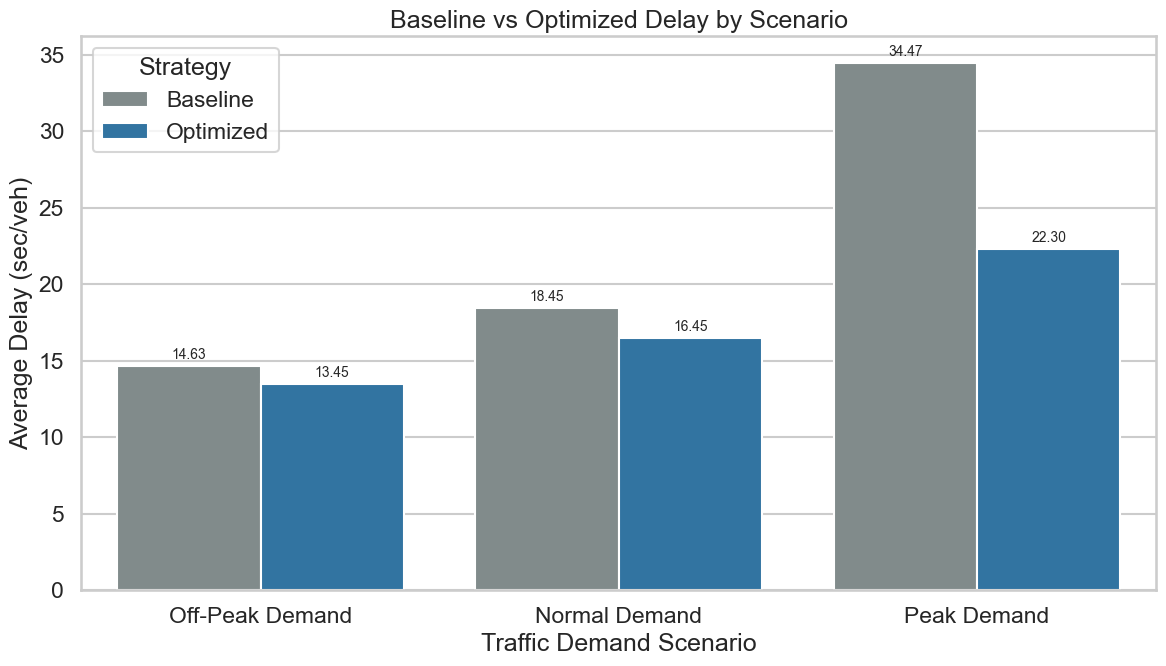

### Visual Description
This chart compares baseline and optimized delay by traffic demand scenario. Delay is measured in sec/veh.

### Insight
Delay reductions are largest in peak demand, indicating higher optimization value under congested conditions.

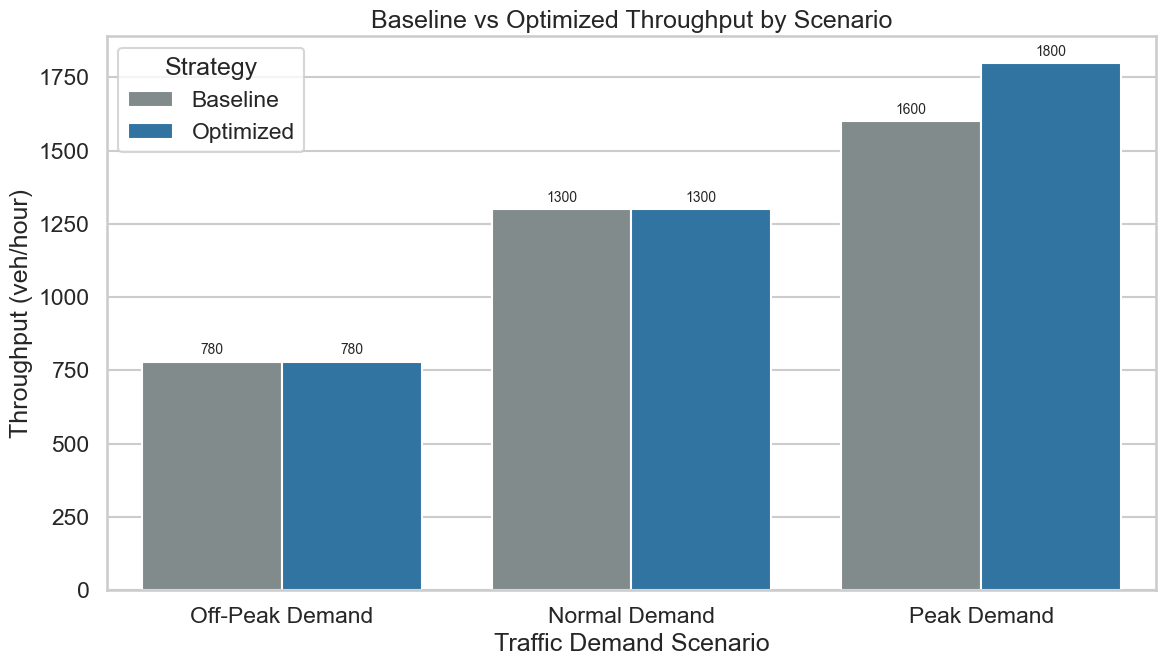

### Visual Description
This chart compares baseline and optimized throughput by scenario, reported in veh/hour.

### Insight
Throughput gains appear most strongly when demand is highest, showing improved capacity utilization from optimized timing.

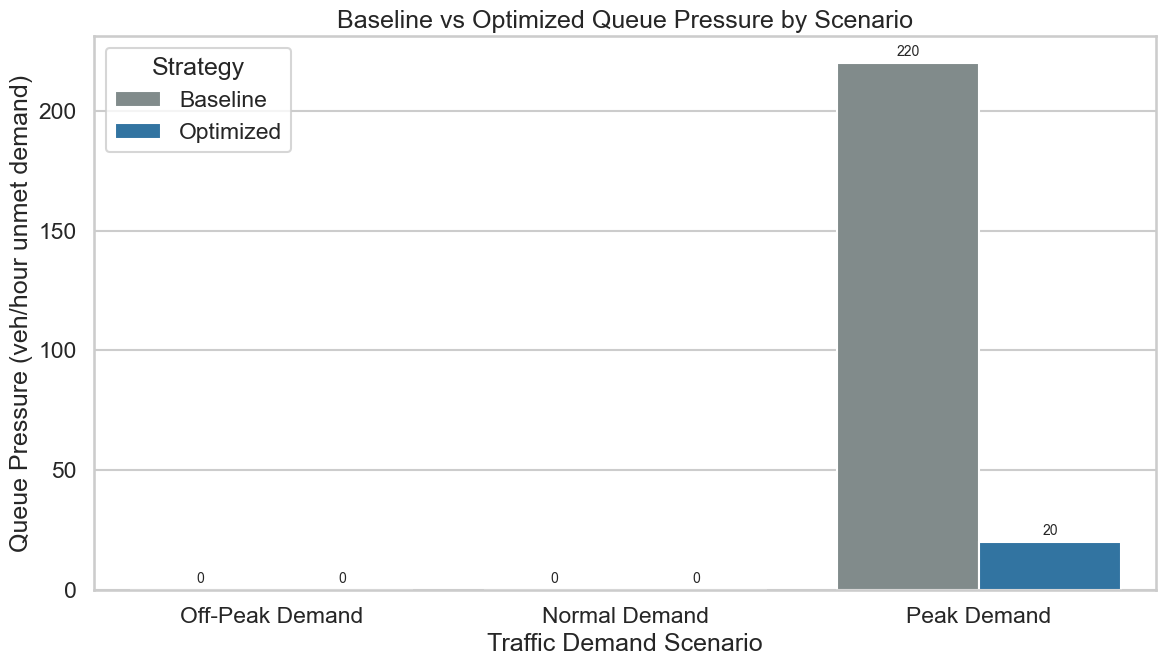

### Visual Description
This chart compares queue pressure by scenario and strategy, where queue pressure is unmet demand in veh/hour.

### Insight
Queue-pressure reductions under optimization indicate lower congestion accumulation and better service balance.

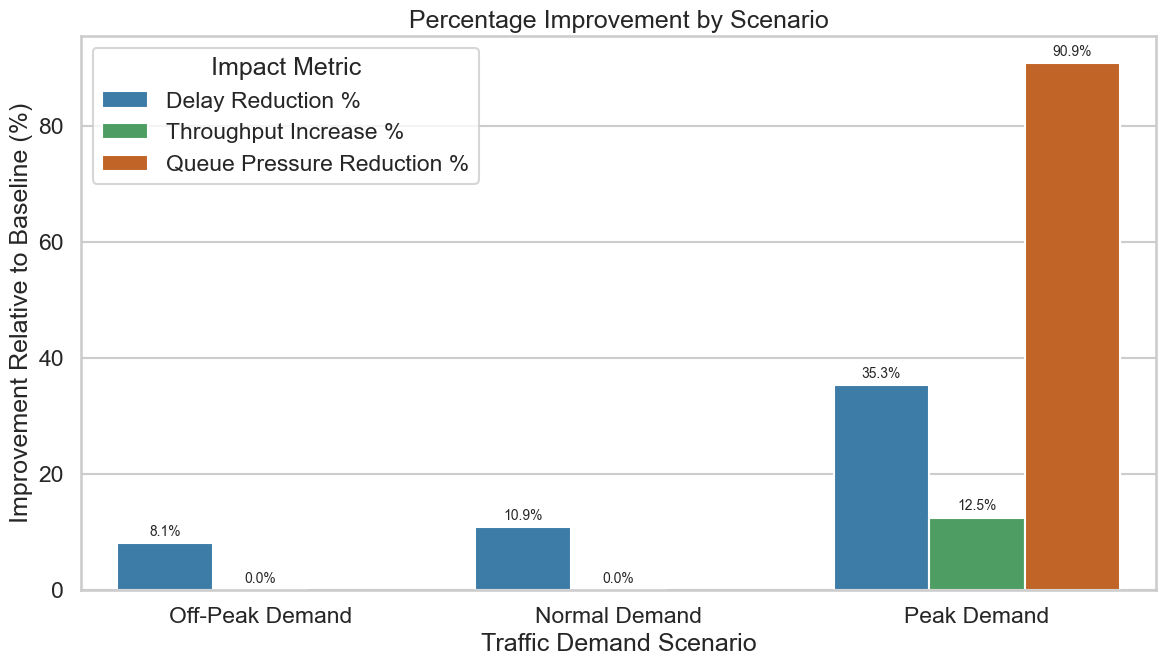

### Visual Description
This chart summarizes percentage changes in delay, throughput, and queue pressure relative to baseline by scenario.

### Insight
The scenario pattern confirms that optimization impact strengthens as demand moves from off-peak to peak congestion.

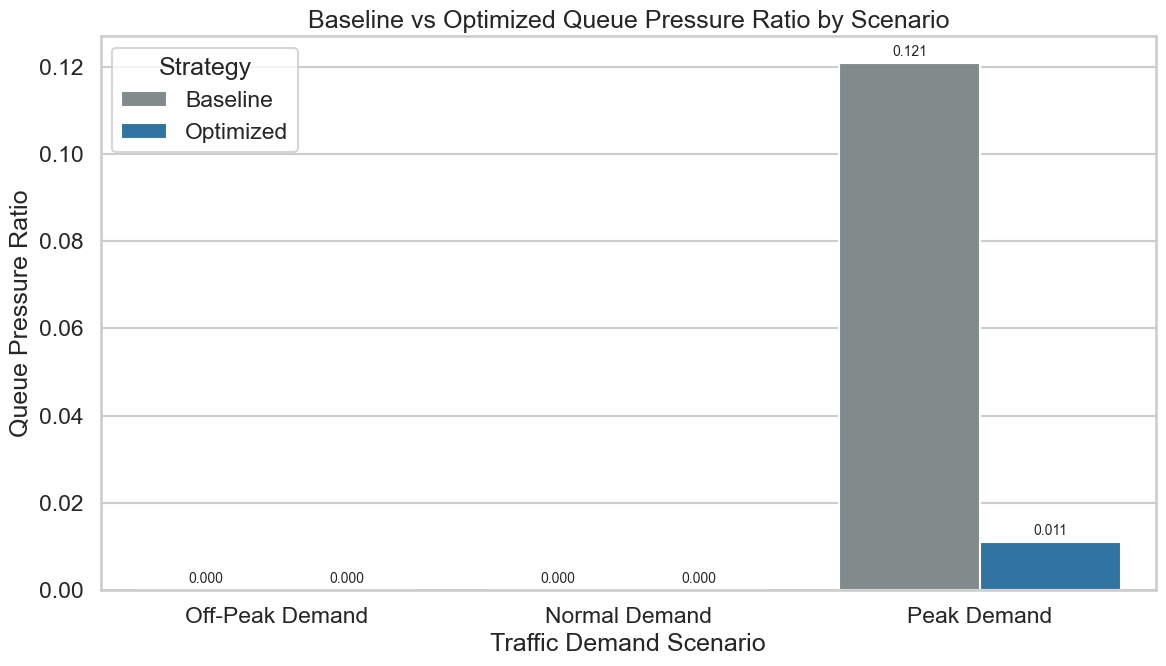

### Visual Description
This chart compares queue pressure ratio by scenario and strategy when the metric is available.

### Insight
Lower optimized ratios indicate improved proportional control of unmet demand under congestion stress.

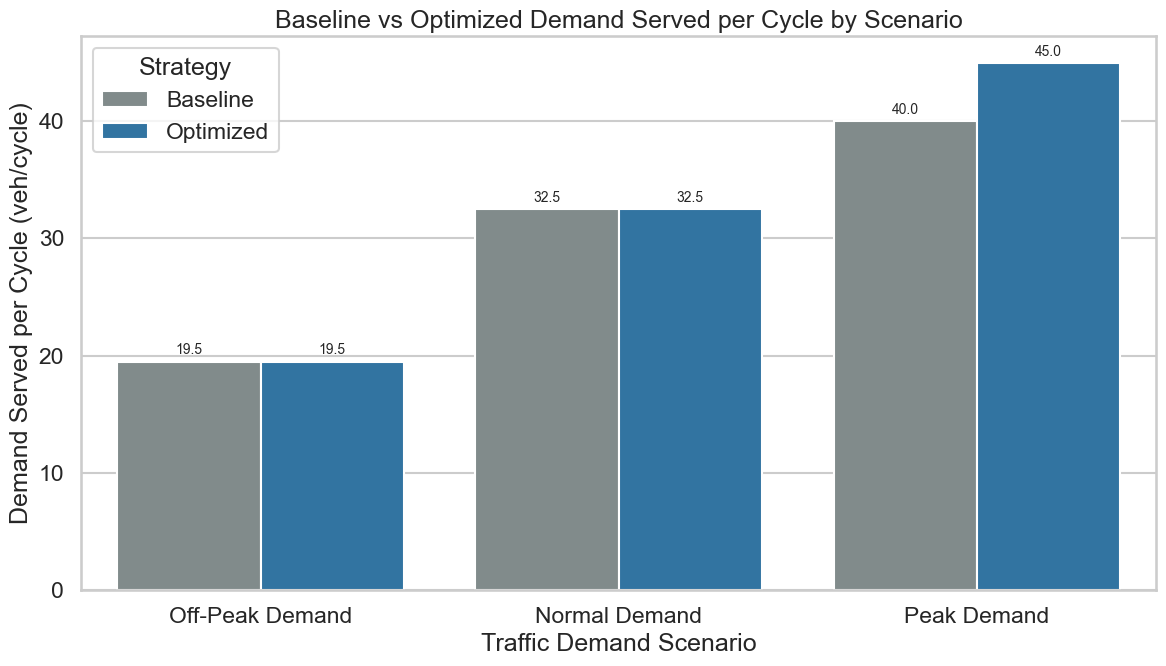

### Visual Description
This chart compares demand served per cycle by scenario and strategy, measured in veh/cycle when available.

### Insight
Higher optimized service per cycle reflects more effective phase-level allocation of fixed cycle time.

In [5]:
sns.set_theme(style='whitegrid', context='talk')
palette = {'Baseline': '#7f8c8d', 'Optimized': '#1f77b4'}
improvement_palette = {
    'Delay Reduction %': '#2c7fb8',
    'Throughput Increase %': '#41ab5d',
    'Queue Pressure Reduction %': '#d95f0e',
}

def add_visual_note(description: str, insight: str) -> None:
    display(Markdown(
        "### Visual Description\n" + description + "\n\n### Insight\n" + insight
    ))



def add_bar_labels(ax, fmt='{:.1f}', suffix=''):
    from matplotlib.container import BarContainer

    for container in ax.containers:
        if not isinstance(container, BarContainer):
            continue

        labels = []
        for bar in container:
            value = bar.get_height()
            if pd.isna(value):
                labels.append('')
            else:
                labels.append(f"{fmt.format(value)}{suffix}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)


plot_df = simulation_df.copy()
plot_df['scenario'] = pd.Categorical(plot_df['scenario'], categories=scenario_order, ordered=True)
plot_df = plot_df.sort_values(['scenario', 'strategy']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=plot_df, x='scenario', y='delay', hue='strategy', palette=palette, ax=ax)
ax.set_title('Baseline vs Optimized Delay by Scenario')
ax.set_xlabel('Traffic Demand Scenario')
ax.set_ylabel('Average Delay (sec/veh)')
add_bar_labels(ax, fmt='{:.2f}')
ax.legend(title='Strategy', frameon=True)
plt.tight_layout()
assets_dir = repo_root / "docs" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(assets_dir / "impact_delay_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
add_visual_note('This chart compares baseline and optimized delay by traffic demand scenario. Delay is measured in sec/veh.', 'Delay reductions are largest in peak demand, indicating higher optimization value under congested conditions.')

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=plot_df, x='scenario', y='throughput', hue='strategy', palette=palette, ax=ax)
ax.set_title('Baseline vs Optimized Throughput by Scenario')
ax.set_xlabel('Traffic Demand Scenario')
ax.set_ylabel('Throughput (veh/hour)')
add_bar_labels(ax, fmt='{:.0f}')
ax.legend(title='Strategy', frameon=True)
plt.tight_layout()
plt.show()
add_visual_note('This chart compares baseline and optimized throughput by scenario, reported in veh/hour.', 'Throughput gains appear most strongly when demand is highest, showing improved capacity utilization from optimized timing.')

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=plot_df, x='scenario', y='queue_pressure', hue='strategy', palette=palette, ax=ax)
ax.set_title('Baseline vs Optimized Queue Pressure by Scenario')
ax.set_xlabel('Traffic Demand Scenario')
ax.set_ylabel('Queue Pressure (veh/hour unmet demand)')
add_bar_labels(ax, fmt='{:.0f}')
ax.legend(title='Strategy', frameon=True)
plt.tight_layout()
plt.show()
add_visual_note('This chart compares queue pressure by scenario and strategy, where queue pressure is unmet demand in veh/hour.', 'Queue-pressure reductions under optimization indicate lower congestion accumulation and better service balance.')

improvement_plot_df = impact_summary_df[
    ['scenario', 'delay_reduction_percent', 'throughput_increase_percent', 'queue_pressure_reduction_percent']
].rename(
    columns={
        'delay_reduction_percent': 'Delay Reduction %',
        'throughput_increase_percent': 'Throughput Increase %',
        'queue_pressure_reduction_percent': 'Queue Pressure Reduction %',
    }
)
improvement_plot_df = improvement_plot_df.melt(id_vars='scenario', var_name='impact_metric', value_name='percent_change')
improvement_plot_df = improvement_plot_df.dropna(subset=['percent_change'])

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=improvement_plot_df,
    x='scenario',
    y='percent_change',
    hue='impact_metric',
    palette=improvement_palette,
    ax=ax,
)
ax.set_title('Percentage Improvement by Scenario')
ax.set_xlabel('Traffic Demand Scenario')
ax.set_ylabel('Improvement Relative to Baseline (%)')
add_bar_labels(ax, fmt='{:.1f}', suffix='%')
ax.legend(title='Impact Metric', frameon=True)
plt.tight_layout()
assets_dir = repo_root / "docs" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(assets_dir / "impact_improvement_by_scenario.png", bbox_inches="tight", dpi=300)
plt.show()
add_visual_note('This chart summarizes percentage changes in delay, throughput, and queue pressure relative to baseline by scenario.', 'The scenario pattern confirms that optimization impact strengthens as demand moves from off-peak to peak congestion.')

if 'queue_pressure_ratio' in plot_df.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=plot_df, x='scenario', y='queue_pressure_ratio', hue='strategy', palette=palette, ax=ax)
    ax.set_title('Baseline vs Optimized Queue Pressure Ratio by Scenario')
    ax.set_xlabel('Traffic Demand Scenario')
    ax.set_ylabel('Queue Pressure Ratio')
    add_bar_labels(ax, fmt='{:.3f}')
    ax.legend(title='Strategy', frameon=True)
    plt.tight_layout()
    plt.show()
add_visual_note('This chart compares queue pressure ratio by scenario and strategy when the metric is available.', 'Lower optimized ratios indicate improved proportional control of unmet demand under congestion stress.')

if 'demand_served_per_cycle' in plot_df.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=plot_df, x='scenario', y='demand_served_per_cycle', hue='strategy', palette=palette, ax=ax)
    ax.set_title('Baseline vs Optimized Demand Served per Cycle by Scenario')
    ax.set_xlabel('Traffic Demand Scenario')
    ax.set_ylabel('Demand Served per Cycle (veh/cycle)')
    add_bar_labels(ax, fmt='{:.1f}')
    ax.legend(title='Strategy', frameon=True)
    plt.tight_layout()
    plt.show()
add_visual_note('This chart compares demand served per cycle by scenario and strategy, measured in veh/cycle when available.', 'Higher optimized service per cycle reflects more effective phase-level allocation of fixed cycle time.')


## Interpretation
Optimized timing is assessed on four operational questions: delay reduction, throughput improvement, queue-pressure reduction, and V/C ratio change. Benefits are expected to be strongest in higher-demand scenarios where baseline control is most constrained.

## Conclusion / Key Takeaways
The evaluation summarizes whether optimization goals were achieved under tested scenarios and provides the final evidence for capstone conclusions on operational effectiveness.